# Problemas de distribución de probabilidad

## Distribución binomial

En teoría de la probabilidad y estadística, la distribución binomial es la distribución de probabilidad discreta que da sólo dos resultados posibles en un experimento; por ejemplo, al lanzar una moneda, puede salir cara o cruz.

In [9]:
!pip install scipy
!pip install matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 40.8 MB/s eta 0:00:00a 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 59.0 MB/s eta 0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [10]:
from scipy.stats import binom

# Definir todas las funciones de probabilidad relacionadas con esta distribución.

def dbinom(x, size, prob = 0.5):
    """
    Calcula la estimación puntual de la distribución binomial.
    """
    result = binom.pmf(k = x, n = size, p = prob, loc = 0)

    return result

def pbinom(q, size, prob = 0.5):
    """
    Calcula el acumulado de la distribución binomial.
    """
    result = binom.cdf(k = q, n = size, p = prob, loc = 0)

    return result

def qbinom(p, size, prob = 0.5):
    """
    Calcula la función cuantil a partir de la distribución binomial.
    """
    result = binom.ppf(q = p, n = size, p = prob, loc = 0)

    return result

def rbinom(n, size, prob = 0.5):
    """
    Genera variables aleatorias a partir de la distribución binomial.
    """
    result = binom.rvs(n = size, p = prob, size = n)

    return result

In [6]:
# Distribución binomial(10, 0.2), dónde n = 10 es el número de ensayos y p = 0.2 es la probabilidad de éxito en un solo ensayo
import numpy as np

np.random.seed(42)

print(f"Probability that a Binomial(10, 0.2) takes the value 2: {dbinom(2, size = 10, prob = 0.2)}")
print(f"Probability that a Binomial(10, 0.2) will take a value less than 2: {pbinom(2, size = 10, prob = 0.2)}")
print(f"Which value of a Binomial(10, 0.2) has a cumulative probability of 0.9? {qbinom(0.9, size = 10, prob = 0.2)}")
print(f"Generate 2000 random values from a Binomial(10, 0.2) distribution: {rbinom(2000, size = 10, prob = 0.2)}")

Probability that a Binomial(10, 0.2) takes the value 2: 0.3019898880000002
Probability that a Binomial(10, 0.2) will take a value less than 2: 0.6777995263999999
Which value of a Binomial(10, 0.2) has a cumulative probability of 0.9? 4.0
Generate 2000 random values from a Binomial(10, 0.2) distribution: [1 4 3 ... 0 0 1]


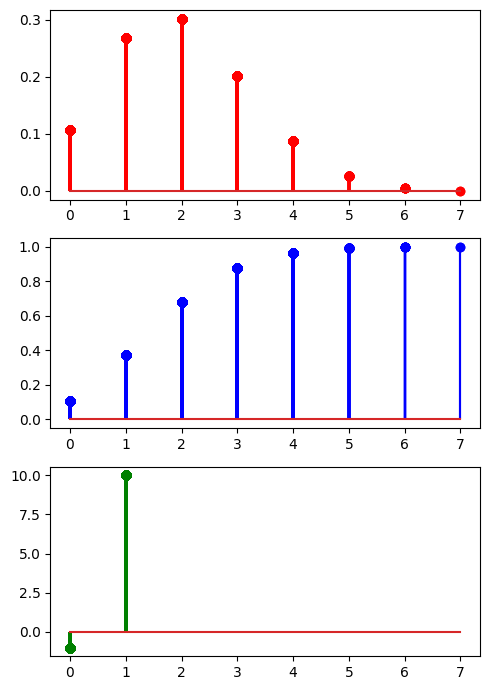

In [11]:
import matplotlib.pyplot as plt

np.random.seed(42)

size = 10
prob = 0.2
data = rbinom(2000, size = 10, prob = 0.2)

pmf = dbinom(data, size = size, prob = prob)
cdf = pbinom(data, size = size, prob = prob)
ppf = qbinom(data, size = size, prob = prob)

fig, axis = plt.subplots(3, 1, figsize = (5, 7))

axis[0].stem(data, pmf, "r-")
axis[1].stem(data, cdf, "b-")
axis[2].stem(data, ppf, "g-")

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

## Ejercicio 1

Escriba las funciones anteriores pero para distribuciones normales y uniformes.

In [12]:
from scipy.stats import norm

def dnorm(x, mean, sd):
    """
    Calcula la estimación puntual de la distribución normal.
    """
    result = norm.pdf(x = x, loc = mean, scale= sd)

    return result

def pnorm(q, mean, sd):
    """
    Calcula el acumulado de la distribución norm.
    """
    result = norm.cdf(x = q, loc = mean, scale=sd)

    return result

def qnorm(p, mean, sd):
    """
    Calcula la función cuantil a partir de la distribución norm.
    """
    result = norm.ppf(q = p, loc = mean, scale=sd)

    return result

def rnorm(size, mean, sd):
    """
    Genera variables aleatorias a partir de la distribución norm.
    """
    result = norm.rvs(loc=mean, scale=sd, size=size, random_state=None)
    return result

In [52]:
# Distribución normal range 10 numbers, mean=5, sd =2
import numpy as np

data = np.random.seed(42)
mean=5
sd=2
# Normal = N(median=5, sd=2)
print(f"Probabilidad puntual Normal(5,2) para el valor 2: {dnorm(2, mean= 5, sd=2)}")
print(f"Probabilidad acumulada Normal(5,2) para el valor 2: {pnorm(2, mean= 5, sd=2)}")
print(f"Probabilidad del quantil para la Normal(5, 2): {qnorm(0.25, mean= 5, sd=2)}")
print(f"Generate 2000 random values para la distribucion Normal (5,2): {rnorm(size=2000, mean = 5, sd = 2)}")

Probabilidad puntual Normal(5,2) para el valor 2: 0.06475879783294587
Probabilidad acumulada Normal(5,2) para el valor 2: 0.06680720126885807
Probabilidad del quantil para la Normal(5, 2): 3.651020499607837
Generate 2000 random values para la distribucion Normal (5,2): [5.99342831 4.7234714  6.29537708 ... 3.2362507  4.67386607 3.51019471]


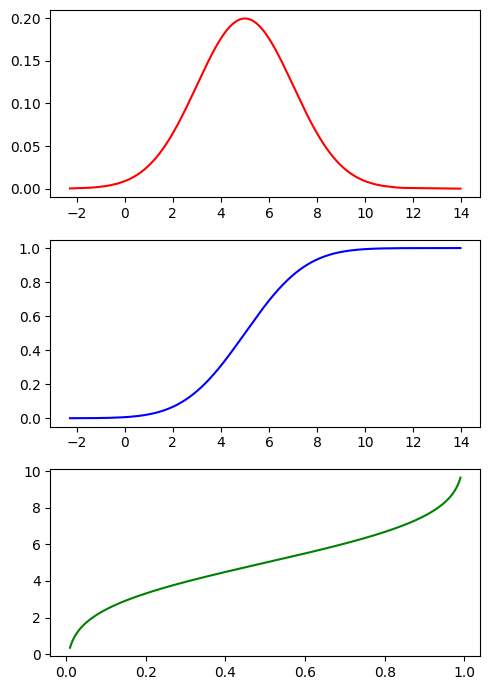

In [21]:
import matplotlib.pyplot as plt

mean=5
sd=2

data = np.sort(rnorm(2000, mean=mean, sd=sd))
p_values = np.linspace(0.01, 0.99, len(data))

pdf = dnorm(data, mean = mean, sd = sd)
cdf = pnorm(data, mean = mean, sd = sd)
ppf = qnorm(p_values, mean = mean, sd = sd)

fig, axis = plt.subplots(3, 1, figsize = (5, 7))

axis[0].plot(data, pdf, "r-")
axis[1].plot(data, cdf, "b-")
axis[2].plot(p_values, ppf, "g-")

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()


Escriba las funciones anteriores pero para distribuciones uniformes.

In [15]:
from scipy.stats import uniform

def dunif(x, min=0, max=1):
    """
    Calcula la estimación puntual de la distribución uniform.
    """
    result = uniform.pdf(x, loc=min,scale=max-min)

    return result

def punif(q, min=0, max=1):
    """
    Calcula el acumulado de la distribución uniform.
    """
    result = uniform.cdf(q, loc=min, scale=max-min)

    return result

def qunif(p, min=0, max=1):
    """
    Calcula la función cuantil a partir de la distribución uniform.
    """
    result = uniform.ppf(p, loc=min, scale=max-min)

    return result

def runif(n, min=0, max=1):
    """
    Genera variables aleatorias a partir de la distribución uniform.
    """
    result = uniform.rvs(size=n, loc=min, scale=max-min)
    return result

In [16]:
import numpy as np

# Definir parámetros: uniforme entre a=2 y b=5
a = 2
b = 15
loc = a
scale = b - a

print(f"Probabilidad puntual de la distribucion Uniforme, para el valor a: {dunif(a, min=a, max=b)}")
print(f"Probabilidad acumulada la distribucion Uniforme para el valor a: {punif(a, min=a, max=b)}")
print(f"Probabilidad del quantil para la distribucion Uniforme: {qunif(0.25, min=a, max=b)}")
print(f"Generate 2000 valores random para la Distribucion Uniforme scale= 15-2 : {runif(n=2000, min = a, max = b)}")

Probabilidad puntual de la distribucion Uniforme, para el valor a: 0.07692307692307693
Probabilidad acumulada la distribucion Uniforme para el valor a: 0.0
Probabilidad del quantil para la distribucion Univorme: 5.25
Generate 2000 valores random para la Distribucion Uniforme scale= 15-2 : [14.12442531  6.97976448 11.48377849 ...  6.11180053 14.68891762
  5.33881047]


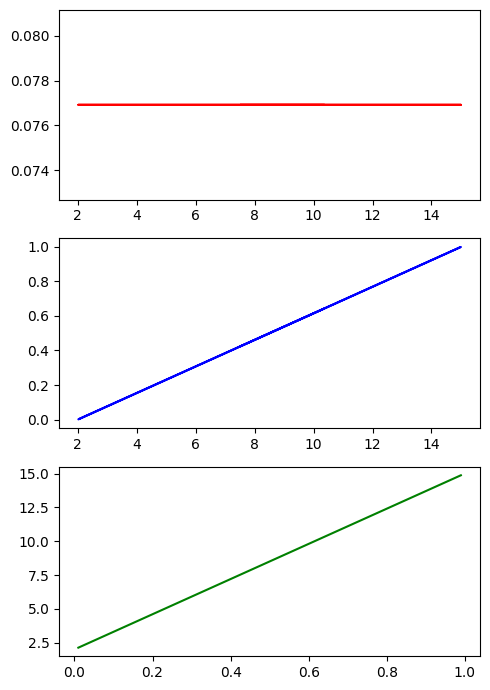

In [19]:
import matplotlib.pyplot as plt

a = 2
b = 15
loc = a
scale = b - a

data = runif(2000, min=a, max=b)
p_values = np.linspace(0.01, 0.99, 1000)

pdf = dunif(data, min=a, max=b)
cdf = punif(data, min=a, max=b)
ppf = qunif(p_values, min=a, max=b)

fig, axis = plt.subplots(3, 1, figsize = (5, 7))

axis[0].plot(data, pdf, "r-")
axis[1].plot(data, cdf, "b-")
axis[2].plot(p_values, ppf, "g-")

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()
